# ResFlex — quick implementation test

A small end-to-end check of the `resflex` package:

1. **Configuration** — build an `input_single`-style dict (simulation length, timestep, appliances, flexible loads).
2. **Simulation** — run `resflex.simulate_one`.
3. **Visualisation** — stacked power profiles (base load + heat pump / EV / water boiler).

This notebook imports `resflex` **straight from the local source tree** (`../resflex/`), so edits to
the package are picked up here with no reinstall and no push. `%autoreload 2` re-imports changed
modules on every cell run — after editing a `.py` file, just re-run the simulation cell (no kernel
restart needed for ordinary function-body edits).

An editable install (`pip install -e .` from the repo root) behaves the same way; the `sys.path`
line below only makes the notebook self-contained when nothing is installed.

In [78]:
# Re-import changed resflex modules automatically on every cell run
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Import resflex from the local checkout (parent of this notebook's folder),
# so local edits to the package apply directly — no reinstall, no push.
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import pandas as pd

import resflex
print("resflex loaded from:", resflex.__file__)

resflex.set_seed(42)  # reproducible run

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
resflex loaded from: /Users/diffels/Documents/GitHub/ResFlex/resflex/__init__.py


## 1. Configuration (`input_single` style)

Fully specifies one household. `nb_days` × `timestep` set the length/resolution of the output
profiles (here 3 days at 15-min steps → 288 rows). `WB` / `EV` / `HP` toggle the flexible loads.

In [79]:
config = {
    # --- simulation horizon / resolution ---
    "nb_days": 7,        # number of days simulated
    "timestep": 15,      # output resampling step [min]
    "year": 2024,        # calendar year (weekday alignment + weather)
    "start_day": 0,      # day-of-year offset for the start
    "flexibility": True,  # also compute the flexibility dataframe
    "output": "csv",

    # --- time-shiftable (white goods) appliances: 0/1 presence ---
    "appliances": {
        "WashingMachine": 1,
        "TumbleDryer": 0,
        "DishWasher": 1,
        "WasherDryer": 0,
    },

    # --- water boiler ---
    "WB": True,
    "WB_data": {"Pmax": 3, "Volume": 200, "T_set": 60},

    # --- electric vehicle ---
    "EV": True,
    "EV_data": {
        "Consumption": 20,   # kWh/100km
        "Capacity": 60,      # kWh
        "Pmax": 5,           # kW
        "eta": 0.95,
        "SoC_target": 0.80,
        "Usage": 15000,      # km/year
    },

    # --- heat pump ---
    "HP": True,
    "HP_data": {"Year": 1980, "Size": 175, "Floors": 3, "P_nom": 3, "COP": 3},

    # --- household composition ---
    "inhabitants": 4,
    "occupations": ["Random", "Random", "Random", "Random"],
}

expected_rows = config["nb_days"] * 24 * 60 // config["timestep"]
print(f"Expected output length: {expected_rows} rows "
      f"({config['nb_days']} days @ {config['timestep']} min)")

Expected output length: 672 rows (7 days @ 15 min)


## 2. Simulation

`simulate_one` returns:
- `df_P` — power per appliance [kW], datetime-indexed
- `df_Flex` — flexibility signals (occupancy, SoC references, …)
- `params` — the completed parameter dict

In [80]:
df_P, df_Flex, params = resflex.simulate_one(
    config, save=False, plot_res=False, print_res=False)

print("df_P shape :", df_P.shape)
print("columns    :", list(df_P.columns))
print("index      :", df_P.index[0], "→", df_P.index[-1])
df_P.head()

Simulation is done. Execution time: 0.27 s.
df_P shape : (672, 6)
columns    : ['DishWasher', 'WashingMachine', 'BaseLoad', 'P_EV', 'P_HP', 'P_WB']
index      : 2024-01-01 00:00:00 → 2024-01-07 23:45:00


,DishWasher,WashingMachine,BaseLoad,P_EV,P_HP,P_WB
2024-01-01 00:00:00,0.0,0.001,0.379252,0.0,0.143335,0.0
2024-01-01 00:15:00,0.0,0.001,0.531252,0.0,0.153573,0.0
2024-01-01 00:30:00,0.0,0.001,0.467919,0.0,0.153573,0.0
2024-01-01 00:45:00,0.0,0.001,0.278052,0.0,0.153573,0.0
2024-01-01 01:00:00,0.0,0.001,0.208735,0.0,0.153573,0.0


In [81]:
# Per-appliance energy over the simulated horizon
energy_kwh = df_P.sum() * (config["timestep"] / 60.0)
print("Total energy consumption (kWh) for the household:", energy_kwh.sum().round(2))
energy_kwh.sort_values(ascending=False).round(2)

Total energy consumption (kWh) for the household: 473.68


P_HP              277.98
P_WB               96.70
BaseLoad           64.01
P_EV               25.42
WashingMachine      7.47
DishWasher          2.11
dtype: float64

## 3. Visualisation of the power profiles

Base load (StROBe baseload + white goods) as the bottom layer, then the flexible loads
(heat pump, EV, water boiler) stacked on top.

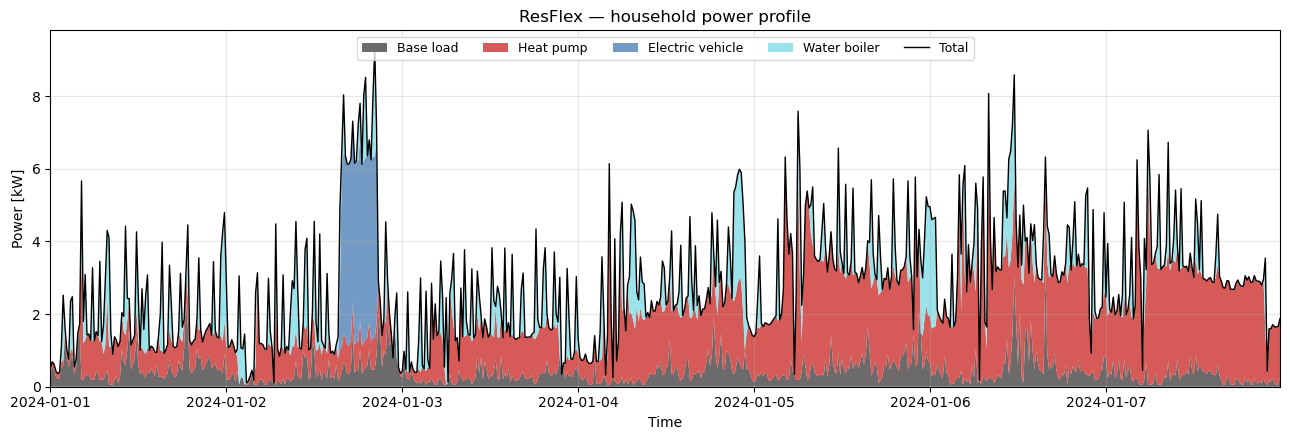

In [82]:
# Group columns into plotting layers (only keep the ones actually present)
white_goods = [c for c in ["WashingMachine", "TumbleDryer", "DishWasher", "WasherDryer"]
               if c in df_P.columns]

layers = pd.DataFrame(index=df_P.index)
layers["Base load"] = df_P.get("BaseLoad", 0)
if white_goods:
    layers["Base load"] = layers["Base load"] + df_P[white_goods].sum(axis=1)
if "P_HP" in df_P.columns:
    layers["Heat pump"] = df_P["P_HP"]
if "P_EV" in df_P.columns:
    layers["Electric vehicle"] = df_P["P_EV"]
if "P_WB" in df_P.columns:
    layers["Water boiler"] = df_P["P_WB"]

colors = ["#646262",  "#d4524f", "#6c96c2", "#95e2ea"][: layers.shape[1]]

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.stackplot(layers.index, layers.T.values, labels=layers.columns, colors=colors, alpha=0.95)
ax.plot(layers.index, layers.sum(axis=1), color="black", lw=1, label="Total")
ax.set_title("ResFlex — household power profile")
ax.set_ylabel("Power [kW]")
ax.set_xlabel("Time")
ax.margins(x=0)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper center", ncol=layers.shape[1] + 1, fontsize=9)
fig.tight_layout()
plt.show()

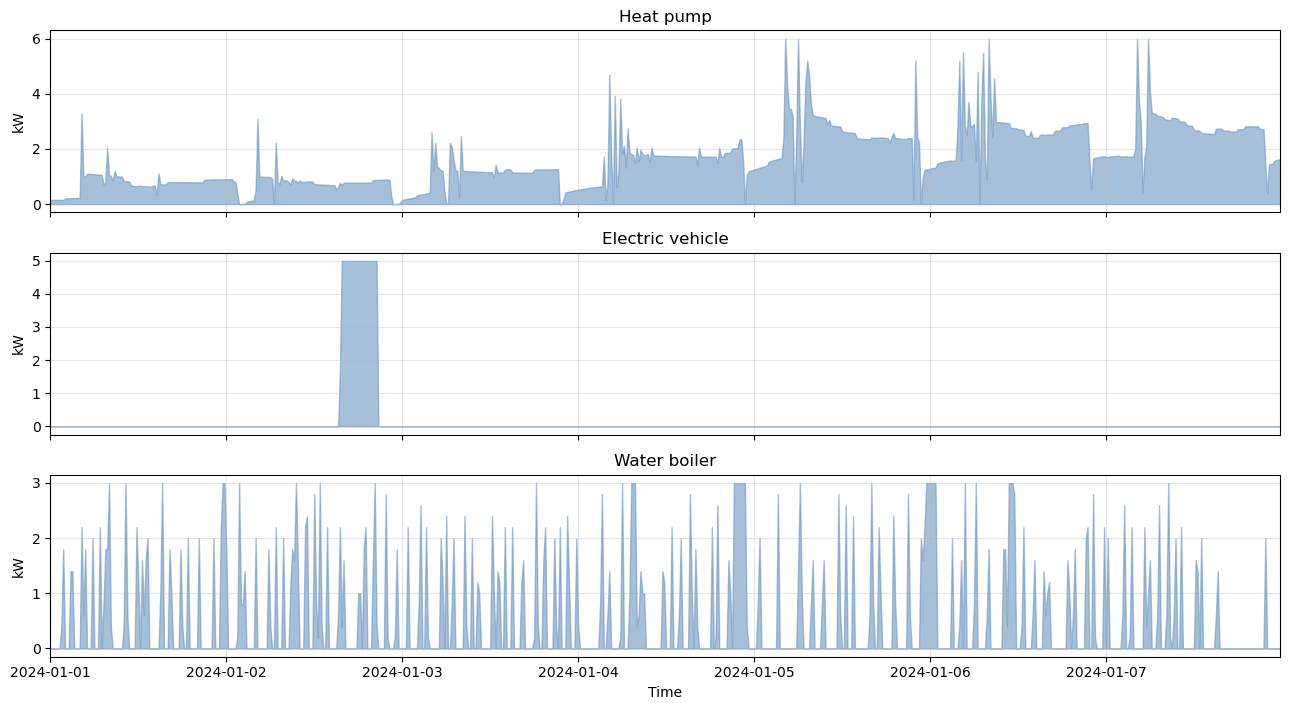

In [83]:
# Individual flexible-load profiles
flex_cols = [c for c in ["P_HP", "P_EV", "P_WB"] if c in df_P.columns]

if flex_cols:
    fig, axes = plt.subplots(len(flex_cols), 1, figsize=(13, 2.4 * len(flex_cols)),
                             sharex=True)
    axes = [axes] if len(flex_cols) == 1 else axes
    names = {"P_HP": "Heat pump", "P_EV": "Electric vehicle", "P_WB": "Water boiler"}
    for ax, col in zip(axes, flex_cols):
        ax.fill_between(df_P.index, df_P[col], color="#6c96c2", alpha=0.6)
        ax.set_title(names[col])
        ax.set_ylabel("kW")
        ax.margins(x=0)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("Time")
    fig.tight_layout()
    plt.show()
else:
    print("No flexible loads enabled in the configuration.")